# K‑Means Project
## California Housing Clustering - Grouping houses by Region and income

MSalaverri

Grouping California houses into six clusters based on their latitude, longitude, and median income. Explore unsupervised learning for geographic and socioeconomic segmentation.

**Type of Problem:** Unsupervised clustering followed by supervised classification.

In [12]:
# IMPORT LIBRARIES

# Data manipulation & visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Saving models
import joblib

import warnings
warnings.filterwarnings('ignore')


In [2]:
# LOADING ORIGINAL DATA
data = "https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv"
df = pd.read_csv(data)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Exploratory Data Analysis

In [3]:
#Dataset dimension
rows, column = df.shape
print("DATASET Dimension:")
print(f'{rows} rows and {column} columns')

DATASET Dimension:
20640 rows and 9 columns


In [4]:
# Lets select only Latitude, Longitude, and MedInc
df = df[["Latitude", "Longitude", "MedInc"]]

rows, column = df.shape
print("\nNEW DATASET Dimension (after selecting only Latitude, Longitude, and MedInc):")
print(f'{rows} rows and {column} columns')

df.head()


NEW DATASET Dimension (after selecting only Latitude, Longitude, and MedInc):
20640 rows and 3 columns


,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


In [5]:
# Get information about range index, number of columns and labels, data types, and the number of cells in each column (non-null values)
print("DATASET General Info:")
df.info()

DATASET General Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Latitude   20640 non-null  float64
 1   Longitude  20640 non-null  float64
 2   MedInc     20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB


In [6]:
#List Missing values
all_missing_values = df.isnull().sum()
print("Missing Values per Column:")
all_missing_values.reset_index()

Missing Values per Column:


,index,0
0,Latitude,0
1,Longitude,0
2,MedInc,0


In [7]:
num_of_zeros = (df == 0).sum()
print("Count of Zeros per Column:")
num_of_zeros.sort_values(ascending=False).reset_index()

Count of Zeros per Column:


,index,0
0,Latitude,0
1,Longitude,0
2,MedInc,0


In [8]:
print("\nDESCRIPTIVE BASIC STATISTIC:")
df.describe()


DESCRIPTIVE BASIC STATISTIC:


,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


### Initial Inspection Summary
The dataset contains 20,640 rows and 9 original columns, each row representing a census block group from California in 1990. The original features included demographic and housing variables.

For this project, we'll selected only the three most relevant columns:

- Latitude: geographic coordinate north–south.

- Longitude: geographic coordinate east–west.

- MedInc: median household income in the block group.

The reduced dataset now has 20,640 rows and 3 columns, with all values fully populated and no missing data.

**Comment:** This simplified dataset is clean, numeric, and well‑structured. Latitude and longitude provide geographic positioning, while median income adds socioeconomic context. Together, these features are suitable for clustering houses into regional and income‑based groups using K‑Means.

## Data Prep

### Duplicates

In [9]:
#Looking for Duplicates
duplicates = df.duplicated()
sum_duplicates = duplicates.sum()

# Verifying Duplicates
print(f"Duplicated Rows: {sum_duplicates}")

df = df.drop_duplicates()
rows, column = df.shape
print("\nNEW DATASET Dimension (after removing duplicates):")
print(f'{rows} rows and {column} columns')

Duplicated Rows: 5

NEW DATASET Dimension (after removing duplicates):
20635 rows and 3 columns


In [10]:
#Show Unique values per column name
n_uniques = df.nunique()
n_uniques.reset_index()

,index,0
0,Latitude,862
1,Longitude,844
2,MedInc,12928


## Preprocessing

### Split

In [15]:
# Split into train and test sets
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)

## K-Means Clustering

### Train & Test

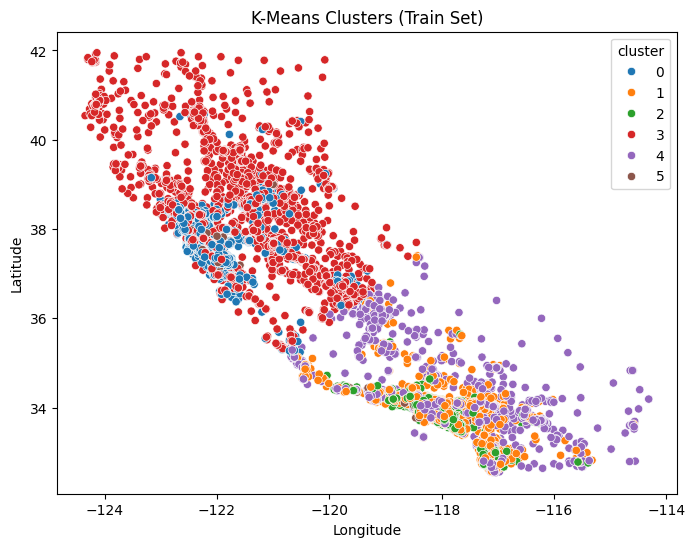

In [16]:
# Train K-Means with 6 clusters
kmeans = KMeans(n_clusters=6, random_state=42)
X_train["cluster"] = kmeans.fit_predict(X_train)

# Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(data=X_train, x="Longitude", y="Latitude", hue="cluster", palette="tab10")
plt.title("K-Means Clusters (Train Set)")
plt.show()

Fit K‑Means on training data, assign cluster labels, and visualize geographic distribution.

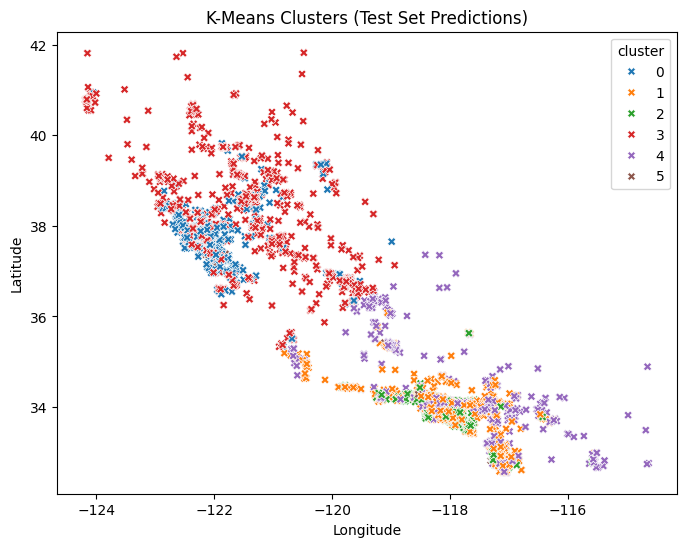

In [17]:
# Predict clusters for test set
X_test["cluster"] = kmeans.predict(X_test)

# Plot test clusters
plt.figure(figsize=(8,6))
sns.scatterplot(data=X_test, x="Longitude", y="Latitude", hue="cluster", palette="tab10", marker="X")
plt.title("K-Means Clusters (Test Set Predictions)")
plt.show()


Use trained K‑Means to predict clusters for test set

### Modeling

In [18]:
# Train supervised model (Random Forest) to predict clusters
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train[["Latitude","Longitude","MedInc"]], X_train["cluster"])

# Predict on test set
y_pred = rf.predict(X_test[["Latitude","Longitude","MedInc"]])

# Evaluate performance
print("Accuracy:", accuracy_score(X_test["cluster"], y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(X_test["cluster"], y_pred))
print("\nClassification Report:\n", classification_report(X_test["cluster"], y_pred))


Accuracy: 0.9951538647928277

Confusion Matrix:
 [[ 585    1    0    1    0    0]
 [   0  992    0    1    2    0]
 [   0    0  317    0    0    0]
 [   2    2    0 1075    3    0]
 [   0    1    0    1 1093    0]
 [   1    0    5    0    0   45]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       587
           1       1.00      1.00      1.00       995
           2       0.98      1.00      0.99       317
           3       1.00      0.99      1.00      1082
           4       1.00      1.00      1.00      1095
           5       1.00      0.88      0.94        51

    accuracy                           1.00      4127
   macro avg       0.99      0.98      0.99      4127
weighted avg       1.00      1.00      1.00      4127



The Random Forest classifier reproduced the K‑Means clusters with very high accuracy (aprox 99.5%).  
Most clusters were predicted almost perfectly, with only minor misclassifications in the smallest group, the last one.  
This confirms that the supervised model can reliably learn the cluster patterns created by K‑Means.

## Final Conclusions  

The K‑Means model successfully grouped California houses into six clusters using **latitude, longitude, and median income.**
These clusters revealed clear geographic and socioeconomic segmentation across the state.

By training a supervised classifier on the cluster labels, we showed that the automatically generated groups can be predicted with strong reliability.
This workflow demonstrates how unsupervised learning can uncover structure in unlabelled data, and how supervised models can then leverage those labels for accurate prediction.

**Conclusion:** Combining clustering with classification provides a powerful approach for housing segmentation, offering both interpretability and predictive capability.


In [19]:
# Save both models
joblib.dump(kmeans, "/workspaces/K-Means-msalaverri/models/kmeans_model.pkl")
joblib.dump(rf, "/workspaces/K-Means-msalaverri/models/RandomForest_classifier.pkl")
print("K-Means and Random Forest saved to 'models'")


K-Means and Random Forest saved to 'models'
